In [1]:
%cd ..
%env
%load_ext autoreload
%autoreload 2

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

from src.datasets.visloc import SatChunkDataset, UAVDataset
from src.evaluation import build_ground_truth, calculate_metrics
from src.retrievers import FAISSRetriever
from src.utils import visualize_embeddings

warnings.filterwarnings("ignore", message=".*invalid escape sequence.*")

NUM_WORKERS = 8
DEVICE = torch.device("cuda")
DTYPE = torch.bfloat16
VISLOC_ROOT = Path(os.environ["VISLOC_ROOT"])
DIFFUSIONSAT_256_CHCKPT = Path(os.environ["DIFFUSIONSAT_256_CHCKPT"])

/root/diffusion-vpr/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/root/diffusion-vpr


In [ ]:
import torch
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline, UniPCMultistepScheduler

from src.embedders import PoolConcatEmbedder
from src.ldm_extractor import LDMExtractor, LDMExtractorCfg


class GeoSynthCannyBackbone(torch.nn.Module):
  def __init__(self, device: torch.device, dtype: torch.dtype):
    super().__init__()
    self.device = device
    self.dtype = dtype

    controlnet = ControlNetModel.from_pretrained("MVRL/GeoSynth-Canny")
    scheduler = UniPCMultistepScheduler.from_pretrained("sd2-community/stable-diffusion-2-1", subfolder="scheduler")

    self.pipe = StableDiffusionControlNetPipeline.from_pretrained(
      "sd2-community/stable-diffusion-2-1",
      controlnet=controlnet,
      scheduler=scheduler,
      torch_dtype=self.dtype,
      low_cpu_mem_usage=False,
    )
    self.pipe = self.pipe.to(device)

    self.vae = self.pipe.vae

    # Diffusion feature extractor from SatDiFuser. Must be configured separately since it requires hyperparameters and to avoid re-loading the UNet.
    self.ldm_extractor: LDMExtractor | None = None

  def set_ldm_extractor_cfg(self, cfg: LDMExtractorCfg):
    self.ldm_extractor_cfg = cfg
    with torch.autocast(str(self.device), dtype=self.dtype):
      self.ldm_extractor = LDMExtractor(cfg, self.pipe)

  @torch.inference_mode()
  def forward(self, imgs: torch.Tensor) -> dict:
    """
    Returns a dict of features from the configured LDM extractor.
    """

    if self.ldm_extractor is None:
      raise ValueError("LDM extractor not configured. Please call set_ldm_extractor_cfg() first.")

    latents = self.vae.encode(imgs.to(dtype=self.dtype)).latent_dist.sample() * 0.18215
    feats, _ = self.ldm_extractor.forward(latents)
    return feats


BATCH_SIZE = 128

SAVE_TIMESTEPS = [8, 7]
NUM_TIMESTEPS = 10
LAYER_IDXS = {"up_blocks": {"attn1": "all"}}


backbone = GeoSynthCannyBackbone(DEVICE, DTYPE)
cfg = LDMExtractorCfg(
  img_size=512,
  save_timesteps=SAVE_TIMESTEPS,
  num_timesteps=NUM_TIMESTEPS,
  layer_idxs=LAYER_IDXS,
  batch_size=BATCH_SIZE,
)
backbone.set_ldm_extractor_cfg(cfg)

embedder = PoolConcatEmbedder(
  feature_dims=backbone.ldm_extractor.collected_dims,
  save_timesteps=SAVE_TIMESTEPS,
)

/root/diffusion-vpr/.venv/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/root/diffusion-vpr/.venv/lib/python3.10/site-packages/diffusers/models/cross_attention.py:30: FutureWarning: Importing from cross_attention is deprecated. Please import from diffusers.models.attention_processor instead.
  deprecate(
The config attributes {'addition_embed_type': None, 'addition_embed_type_num_heads': 64, 'addition_time_embed_dim': None, 'conditioning_channels': 3, 'encoder_hid_dim': None, 'encoder_hid_dim_type': None, 'mid_block_type': 'UNetMidBlock2DCrossAttn', 'num_attention_heads': None, 'transformer_layers_per_block': 1} were passed to ControlNetModel, but are not expected and will be ignored. Please verify your confi

In [3]:
@torch.inference_mode()
def extract_embeddings(loader: DataLoader) -> tuple[torch.Tensor, list[float], list[float]]:
  embeddings = []
  all_lats = []
  all_lons = []

  for imgs, lats, lons in tqdm(loader, desc="Building embeddings"):
    imgs = imgs.to(DEVICE, dtype=DTYPE)
    feats = backbone(imgs)
    embs = embedder(feats)

    embeddings.append(embs.cpu())
    all_lats.extend(lats)
    all_lons.extend(lons)

  embeddings = torch.cat(embeddings, dim=0)
  embeddings = F.normalize(embeddings, p=2, dim=1)

  return embeddings, all_lats, all_lons

In [4]:
FLIGHT_ID = "03"

CHUNK_PIXELS = 512
CHUNK_STRIDE = CHUNK_PIXELS // 4
MAP_SCALE_FACTOR = 0.25


inference_sat_transforms = transforms.Compose(
  [
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
  ]
)
inference_uav_transforms = transforms.Compose(
  [
    transforms.Resize(512),
    transforms.CenterCrop((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
  ]
)


gallery_dataset = SatChunkDataset(
  VISLOC_ROOT,
  FLIGHT_ID,
  chunk_pixels=CHUNK_PIXELS,
  stride_pixels=CHUNK_STRIDE,
  scale_factor=MAP_SCALE_FACTOR,
  transform=inference_sat_transforms,
)
gallery_loader = DataLoader(
  gallery_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

uav_dataset = UAVDataset(VISLOC_ROOT, FLIGHT_ID, transform=inference_uav_transforms)
uav_loader = DataLoader(uav_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Gallery: {len(gallery_dataset)} satellite chunks")
print(f"Query:   {len(uav_dataset)} UAV images")

Gallery: 2860 satellite chunks
Query:   768 UAV images


In [5]:
gallery_embeddings, _, _ = extract_embeddings(gallery_loader)
query_embeddings, uav_lats, uav_lons = extract_embeddings(uav_loader)

Building embeddings:   0%|          | 0/23 [00:00<?, ?it/s]

Building embeddings: 100%|██████████| 6/6 [01:17<00:00, 12.99s/it]


In [6]:
uav_coords = np.stack([uav_lats, uav_lons], axis=1)
ground_truth = build_ground_truth(uav_coords, gallery_dataset.chunk_bboxes)

print(f"{len(ground_truth)} UAV queries, avg {np.mean([len(gt) for gt in ground_truth]):.1f} matching chunks each")

retriever = FAISSRetriever(gallery_embeddings)
distances, preds = retriever.search(query_embeddings, k=10)

metrics = calculate_metrics(preds, ground_truth)

print(metrics)

768 UAV queries, avg 15.9 matching chunks each
{'Recall@1': 0.006510416666666667, 'Recall@5': 0.018229166666666668, 'Recall@10': 0.033854166666666664}


In [7]:
entry = {
  "model": "geosynth-canny-SatDiFuser-extraction",
  "model_extra": {
    "embedder": "PoolConcatEmbedder",
    **dict(cfg.__dict__.items()),
  },
  "dataset": "visloc",
  "dataset_extra": {
    "flight_id": FLIGHT_ID,
    "chunk_pixels": CHUNK_PIXELS,
    "chunk_stride": CHUNK_STRIDE,
    "map_scale_factor": MAP_SCALE_FACTOR,
  },
  "emb_dim": gallery_embeddings.shape[1],
  "n_gallery": len(gallery_dataset),
  "n_query": len(uav_dataset),
  "retriever_type": retriever.type,
  **metrics,
}

entry

{'model': 'geosynth-canny-SatDiFuser-extraction',
 'model_extra': {'embedder': 'PoolConcatEmbedder',
  'img_size': 512,
  'batch_size': 128,
  'save_timesteps': [8, 7],
  'num_timesteps': 10,
  'layer_idxs': {'up_blocks': {'attn1': 'all'}},
  'diffusion_mode': 'inversion',
  'prompt': 'A satellite image',
  'negative_prompt': '',
  'resize_outputs': -1,
  'max_i': None,
  'min_i': None},
 'dataset': 'visloc',
 'dataset_extra': {'flight_id': '03',
  'chunk_pixels': 512,
  'chunk_stride': 128,
  'map_scale_factor': 0.25},
 'emb_dim': 13440,
 'n_gallery': 2860,
 'n_query': 768,
 'retriever_type': 'ip',
 'Recall@1': 0.006510416666666667,
 'Recall@5': 0.018229166666666668,
 'Recall@10': 0.033854166666666664}

In [8]:
results_path = Path("results/1-baseline-comparison.csv")
results = pd.read_csv(results_path).to_dict(orient="records") if results_path.exists() else []

results.append(entry)

pd.DataFrame(results).sort_values("Recall@1", ascending=False).to_csv(results_path, index=False)


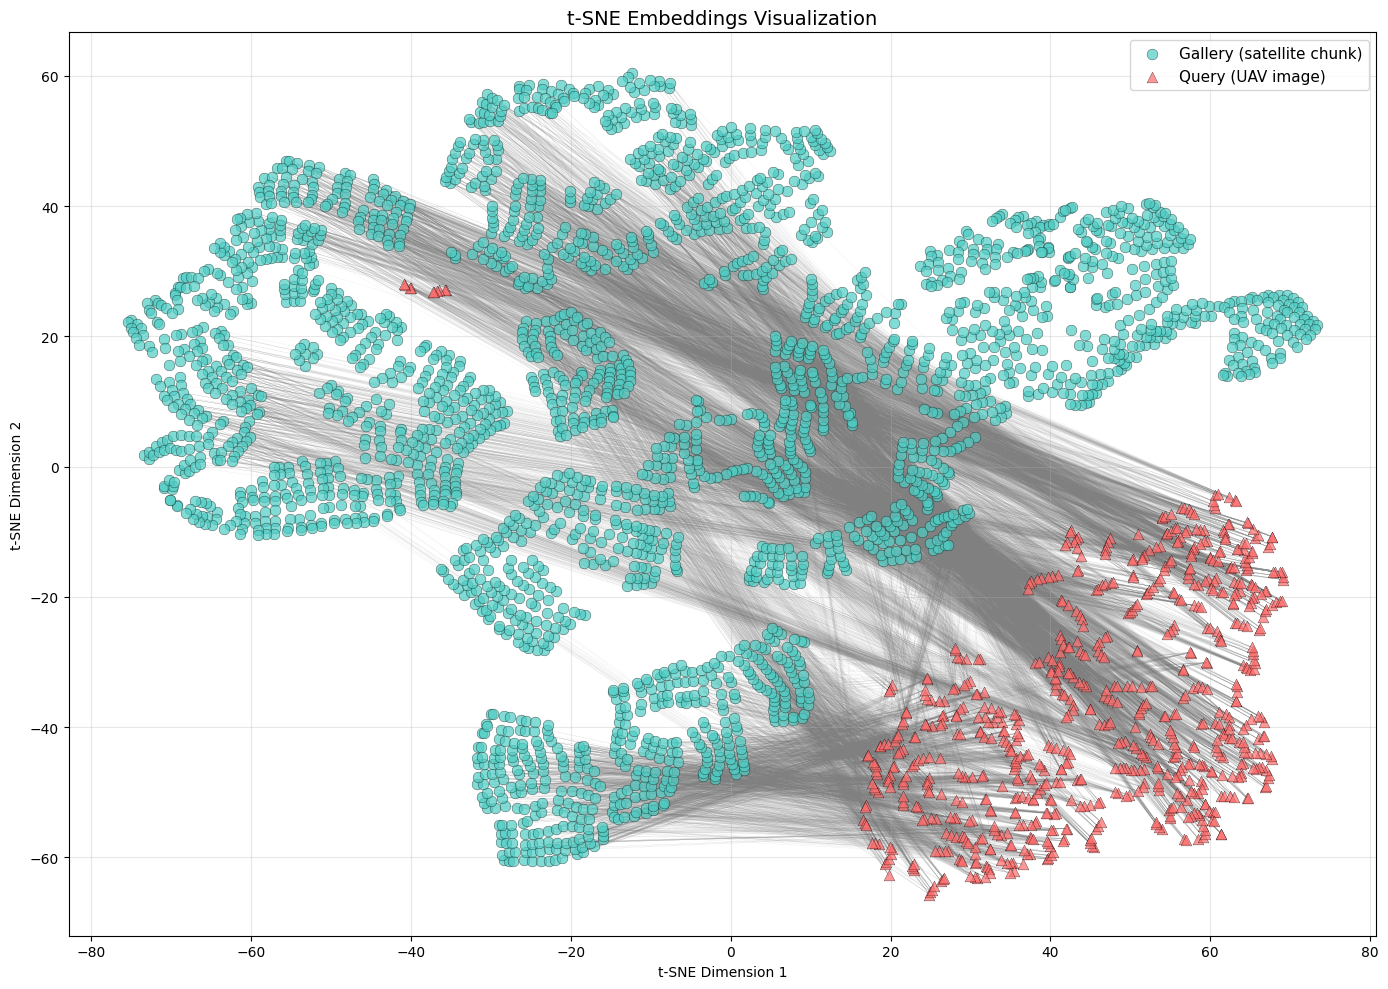

In [12]:
visualize_embeddings(gallery_embeddings, query_embeddings, ground_truth)